In [1]:
#Keşifçi Veri Analizi (EDA)
import pandas as pd
pd.set_option('display.max_columns', None) #Bütün değerleri eksiksiz görmek için

df = pd.read_csv(r"C:\Users\Mustafa\Desktop\Customer_Churn_Prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("veri Seti Boyutu:",df.shape)

print("\n--- Veri Tipleri ve Eksik Değer Özeti ---")

df.info() #Sütün bazlı teknik özet bilgisi için kullanılır.



veri Seti Boyutu: (7043, 21)

--- Veri Tipleri ve Eksik Değer Özeti ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-n

# İlk bakış 
-> Verimizde eksik değer yoktur.
-> "TotalCharges" veri tipi "str" olarak verilmiş ama finansal tutarlar "float64" veri tipinde olmalıdır
-> "CustomerID" gereksiz değişkendir sonraki adımda kaldırılmalıdır.
-> "SeniorCitizen" veri tipi int64 olsada aslında katagorik bir değişkendir. 

In [3]:
df=df.drop('customerID',axis=1) #1. Analize katkısı olmayan customerID sütununun silinmesi

# 2. TotalCharges sütununun sayısal (float) tipe zorlanması
# errors='coerce' parametresi, sayıya çevrilemeyen boşluk karakterlerini matematiksel eksik değere (NaN) dönüştürür.
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

print(df.isnull().sum())




gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


# !!! Çok Önemli Bir Bilgi
Pandas kütüphanesi, CSV dosyasını okurken bir sütunda tek bir boşluk karakteri (" ") dahi tespit etse, veri kaybını önlemek amacıyla tüm sütunu metin formatına çevirir. İlgili veri setinde, henüz ilk ayını doldurmamış (tenure = 0) müşterilere ait fatura kesilmediği için toplam harcama kısımları boş bırakılmış ve sisteme metin karakteri olan boşluk (" ") şeklinde aktarılmıştır. Bu nedenle .isnull() komutu boşluk karakterini bir değer olarak kabul etmiş ve eksik veri olarak saymamıştır.

# Böylece 11 adet gizli eksik veri açığa çıkmıştır.

# eksik veriler için iki standart yaklaşım mevcuttur.
Satırları Silmek: Veri kaybı oranı çok düşük olduğu için model performansını etkilemez.
Değer Atamak: Bu müşterilerin hizmet süresi sıfır olduğu için toplam harcamalarının da sıfır (0) olması mantıksal olarak doğrudur.




In [4]:
df["TotalCharges"]=df["TotalCharges"].fillna(0) # 11 adet eksik verinin 0 ile doldurulması

print("Kalan Eksik Veri Sayısı:\n", df.isnull().sum().max())

df['Churn']=df["Churn"].map({'Yes': 1, "No":0})

print(df[['TotalCharges',"Churn"]].head())
print("\nKalan Eksik Veri Sayisi",df["TotalCharges"].isnull().sum())


Kalan Eksik Veri Sayısı:
 0
   TotalCharges  Churn
0         29.85      0
1       1889.50      0
2        108.15      1
3       1840.75      0
4        151.65      1

Kalan Eksik Veri Sayisi 0


Eksik veriler mantıksal olarak sıfır ile dolduruldu.
Churn değişkeni 1 ve 0 ile değiştirildi.

In [5]:
tekrar_eden_sayisi=df.duplicated().sum() #Tekrar eden (mükerrer) satır kontrolü

print("\n--- Churn Sınıf Dağılımı(%) ---")
print(df["Churn"].value_counts(normalize=True)*100)

print("\n--- Kategorik Değişkenlerin Benzersiz Değer Sayıları ---")
kategorik_sutunlar=df.select_dtypes(include=['object']).columns
print(df[kategorik_sutunlar].nunique())



--- Churn Sınıf Dağılımı(%) ---
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

--- Kategorik Değişkenlerin Benzersiz Değer Sayıları ---
gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64


C:\Users\Mustafa\AppData\Local\Temp\ipykernel_16608\1008352339.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kategorik_sutunlar=df.select_dtypes(include=['object']).columns


->Sınıf dengesizliği mevcuttur.Bu sebeple, modelin başarısı ölçülürken salt Doğruluk (Accuracy) metriği kullanılmamalı; Kesinlik (Precision), Duyarlılık (Recall) ve F1 Skoru gibi metrikler dikkate alınmalıdır.
->

In [6]:
internet_hizmetleri=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                       'TechSupport', 'StreamingTV', 'StreamingMovies']
for sutun in internet_hizmetleri:
    df[sutun]=df[sutun].replace({'No internet service': 'No'})

print("Sadeleştirme Sonrası Benzersiz Sınıf Sayıları:")
print(df[['MultipleLines', 'OnlineSecurity', 'TechSupport']].nunique())
print("\nGüncel Veri Seti Boyutu:", df.shape)

Sadeleştirme Sonrası Benzersiz Sınıf Sayıları:
MultipleLines     3
OnlineSecurity    2
TechSupport       2
dtype: int64

Güncel Veri Seti Boyutu: (7043, 20)


-> Veri seti incelendiğinde 6 sütunu kapsayacak şekilde birbirine tekrar etme durumu oluşmuştur. BU sebeple Replace yapılmıştır. MultipleLines düzelmemiştir. Alttaki kodda düzeltilecektir.

Güncel MultipleLines Sınıf Sayısı: 2


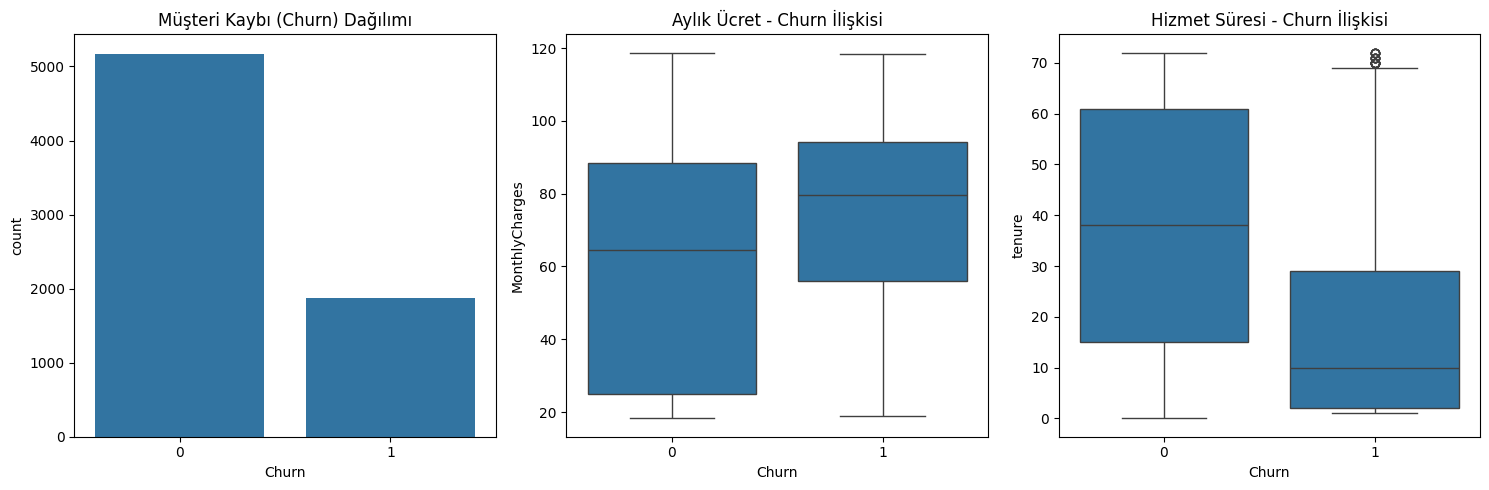

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. MultipleLines değişkenindeki metin formatı sorununun çözümü
df["MultipleLines"]=df["MultipleLines"].str.replace('No phone service', 'No', regex=False)
print("Güncel MultipleLines Sınıf Sayısı:", df['MultipleLines'].nunique())

# 2. Grafik alanının yapılandırılması
plt.figure(figsize=(15,5))

# 3. Churn (Kayıp) Dağılımı
plt.subplot(1,3,1)
sns.countplot(data=df,x="Churn")
plt.title('Müşteri Kaybı (Churn) Dağılımı')
# 4. Aylık Ücret (MonthlyCharges) Aykırı Değer ve İlişki Kontrolü
plt.subplot(1,3,2)
sns.boxplot(data=df,y="MonthlyCharges",x="Churn")
plt.title("Aylık Ücret - Churn İlişkisi")
# 5. Hizmet Süresi (tenure) Aykırı Değer ve İlişki Kontrolü
plt.subplot(1,3,3)
sns.boxplot(data=df,y='tenure', x='Churn')
plt.title('Hizmet Süresi - Churn İlişkisi')

plt.tight_layout()
plt.show()


->Kaybedilen müşterilerin (1 sınıfı) aylık ücret medyanı yaklaşık 80 birim seviyesindedir. Kalan müşterilerin (0 sınıfı) medyanı ise yaklaşık 65 birimdir. Kutuların konumlarına bakıldığında, 1 sınıfının kutusu genel olarak daha yukarıdadır.
->Grafikte 1 sınıfına ait kutunun üst çizgisinin dışında kalan küçük halkalar (noktalar) bulunmaktadır. Bu noktalar istatistiksel sınırların dışına taşan aykırı değerleri temsil eder. Bu durum, 60-70 ay gibi çok uzun süredir hizmet alan nadir sayıdaki sadık müşterinin de sistemi terk ettiğini göstermektedir.

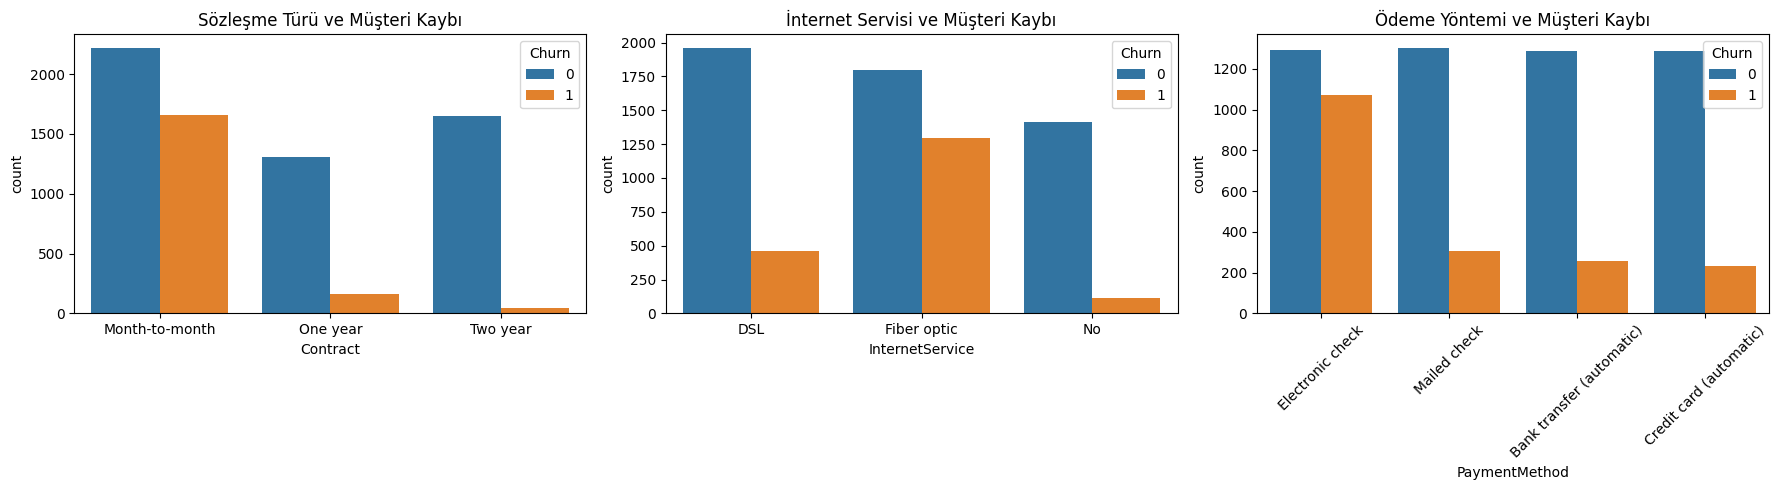

In [21]:
plt.figure(figsize=(18,5))

# 1. Sözleşme Türü (Contract) ve Churn İlişkisi
plt.subplot(1,3,1)
sns.countplot(data=df,x="Contract", hue="Churn")
plt.title('Sözleşme Türü ve Müşteri Kaybı')
# 2. İnternet Servisi (InternetService) ve Churn İlişkisi
plt.subplot(1,3,2)
sns.countplot(data=df,x="InternetService", hue="Churn")
plt.title('İnternet Servisi ve Müşteri Kaybı')
# 3. Ödeme Yöntemi (PaymentMethod) ve Churn İlişkisi
plt.subplot(1,3,3)
sns.countplot(data=df,x="PaymentMethod", hue="Churn")
plt.title('Ödeme Yöntemi ve Müşteri Kaybı')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()